# Notebook de revue du pipeline de segmentation cellulaire

Objectifs:
- harmoniser les parametres de decodage StarDist avec le reste du pipeline
- expliciter les metriques et leur interpretation
- ajouter des stress tests simples (bruit + proxy contact/chevauchement)

Mode d'emploi:
1. Execute les cellules dans l'ordre.
2. Commence avec MAX_IMAGES=50 pour un sanity check rapide, puis passe a None pour tout le split.
3. Les metriques ne mesurent pas toutes la meme chose: lis bien les definitions avant de comparer.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

import ioumatch

from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import remove_small_objects, h_maxima

from cellpose import models as cp_models

from src.pannuke_dataset import PannukePreparedDataset
from models.lit_unet_pannuke import UNetLightning
from models.lit_stardist_pannuke import StarDistLightning
from models.stardist import stardist_decode

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = Path("data/prepared/pannuke")
MORPH_CSV = DATA_ROOT / "pannuke_morphology_with_classes.csv"

print("DEVICE:", DEVICE)
print("DATA_ROOT:", DATA_ROOT)
print("MORPH_CSV:", MORPH_CSV, MORPH_CSV.exists())


DEVICE: cuda
DATA_ROOT: data\prepared\pannuke
MORPH_CSV: data\prepared\pannuke\pannuke_morphology_with_classes.csv True


In [2]:
def get_raw_dataset(split: str):
    return PannukePreparedDataset(
        root=DATA_ROOT,
        split=split,
        transform=None,
        return_image_name=True,
    )


def get_sample(ds, idx):
    img_t, gt_inst_t, _, name = ds[idx]
    img = img_t.numpy()  # (3,H,W)
    gt_inst = gt_inst_t.numpy().astype(np.int32)
    return img, gt_inst, name


In [3]:
def dice_iou_bin(pred_bin: np.ndarray, gt_bin: np.ndarray):
    pred = pred_bin.astype(bool)
    gt = gt_bin.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    dice = (2 * inter) / (pred.sum() + gt.sum() + 1e-8)
    iou = inter / (union + 1e-8)
    return float(dice), float(iou)


def f1_instance(pred_inst: np.ndarray, gt_inst: np.ndarray, iou_thr: float = 0.5):
    res = ioumatch.evaluate_image(
        pred_inst.astype(np.int32),
        gt_inst.astype(np.int32),
        threshold=iou_thr,
        method="greedy",
        inclusive=False,
        normalize=False,
    )
    TP, FP, FN = int(res["tp"]), int(res["fp"]), int(res["fn"])
    f1 = (2 * TP) / (2 * TP + FP + FN + 1e-8)
    return float(f1), TP, FP, FN, res["iou_matrix"]


def _iou_binary(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum(dtype=np.float32)
    union = np.logical_or(a, b).sum(dtype=np.float32)
    return float(inter / union) if union > 0 else 0.0


def match_gt_instances(pred_inst: np.ndarray, gt_inst: np.ndarray, iou_thr=0.5):
    # GT-centric matching (one GT instance at a time)
    gt_ids = np.unique(gt_inst)
    gt_ids = gt_ids[gt_ids > 0]
    if gt_ids.size == 0:
        return pd.DataFrame(columns=["instance_id", "iou_max", "TP"])

    pred_ids = np.unique(pred_inst)
    pred_ids = pred_ids[pred_ids > 0]
    if pred_ids.size == 0:
        return pd.DataFrame({
            "instance_id": gt_ids.astype(int),
            "iou_max": np.zeros(gt_ids.size, dtype=float),
            "TP": np.zeros(gt_ids.size, dtype=int),
        })

    pred_masks = {pid: (pred_inst == pid) for pid in pred_ids}

    iou_max_list = []
    for gid in gt_ids:
        gt_mask = (gt_inst == gid)
        best = 0.0
        for pid in pred_ids:
            iou = _iou_binary(gt_mask, pred_masks[pid])
            if iou > best:
                best = iou
        iou_max_list.append(best)

    iou_max = np.array(iou_max_list, dtype=float)
    TP = (iou_max >= iou_thr).astype(int)

    return pd.DataFrame({
        "instance_id": gt_ids.astype(int),
        "iou_max": iou_max,
        "TP": TP
    })

def compute_iou_matrix(pred_inst: np.ndarray, gt_inst: np.ndarray):
    gt_ids = np.unique(gt_inst)
    gt_ids = gt_ids[gt_ids > 0]
    pred_ids = np.unique(pred_inst)
    pred_ids = pred_ids[pred_ids > 0]
    gt_masks = {gid: (gt_inst == gid) for gid in gt_ids}
    pred_masks = {pid: (pred_inst == pid) for pid in pred_ids}
    iou_mat = np.zeros((gt_ids.size, pred_ids.size), dtype=np.float32)
    for gi, gid in enumerate(gt_ids):
        gmask = gt_masks[gid]
        for pi, pid in enumerate(pred_ids):
            pmask = pred_masks[pid]
            inter = np.logical_and(gmask, pmask).sum(dtype=np.float32)
            union = np.logical_or(gmask, pmask).sum(dtype=np.float32)
            iou_mat[gi, pi] = inter / (union + 1e-8)
    return gt_ids, pred_ids, gt_masks, pred_masks, iou_mat


def compute_matches_for_pq(iou_mat: np.ndarray, thr: float = 0.5):
    iou = iou_mat.copy()
    gt_n, pred_n = iou.shape
    matched_gt = set()
    matched_pred = set()
    matches = []
    while True:
        if iou.size == 0:
            break
        max_idx = np.unravel_index(np.argmax(iou), iou.shape)
        max_iou = iou[max_idx]
        if max_iou < thr:
            break
        gi, pi = max_idx
        matches.append((gi, pi, float(max_iou)))
        matched_gt.add(gi)
        matched_pred.add(pi)
        iou[gi, :] = -1
        iou[:, pi] = -1
    return matches, matched_gt, matched_pred


def compute_aji_pq(pred_inst: np.ndarray, gt_inst: np.ndarray, iou_thr: float = 0.5):
    gt_ids, pred_ids, gt_masks, pred_masks, iou_mat = compute_iou_matrix(pred_inst, gt_inst)
    matches, matched_gt, matched_pred = compute_matches_for_pq(iou_mat, thr=iou_thr)

    # PQ
    TP = len(matches)
    FP = len(pred_ids) - len(matched_pred)
    FN = len(gt_ids) - len(matched_gt)
    sum_iou = float(sum(m[2] for m in matches))
    pq = sum_iou / (TP + 0.5 * FP + 0.5 * FN + 1e-8)

    # AJI
    inter_sum = 0.0
    union_sum = 0.0
    matched_pred_ids = set()
    matched_gt_ids = set()
    for gi, pi, iou_val in matches:
        gid = gt_ids[gi]
        pid = pred_ids[pi]
        gmask = gt_masks[gid]
        pmask = pred_masks[pid]
        inter = np.logical_and(gmask, pmask).sum(dtype=np.float32)
        union = np.logical_or(gmask, pmask).sum(dtype=np.float32)
        inter_sum += float(inter)
        union_sum += float(union)
        matched_pred_ids.add(pid)
        matched_gt_ids.add(gid)

    # add unmatched areas to denominator
    unmatched_gt = [gid for gid in gt_ids if gid not in matched_gt_ids]
    unmatched_pred = [pid for pid in pred_ids if pid not in matched_pred_ids]
    for gid in unmatched_gt:
        union_sum += float(gt_masks[gid].sum(dtype=np.float32))
    for pid in unmatched_pred:
        union_sum += float(pred_masks[pid].sum(dtype=np.float32))

    aji = inter_sum / (union_sum + 1e-8) if union_sum > 0 else 0.0

    return float(aji), float(pq)


In [4]:
# U-Net postprocess
def unet_prob_to_instances(prob, thr=0.5, min_size=20, h=1.5):
    bin_mask = prob > thr
    bin_mask = remove_small_objects(bin_mask, min_size=min_size)

    if bin_mask.sum() == 0:
        return np.zeros_like(prob, dtype=np.int32)

    dist = ndi.distance_transform_edt(bin_mask)
    seeds = h_maxima(dist, h=h)
    seeds &= bin_mask

    markers, _ = ndi.label(seeds)
    if markers.max() == 0:
        markers, _ = ndi.label(bin_mask)

    labels = watershed(-dist, markers, mask=bin_mask)
    return labels.astype(np.int32)


In [5]:
# Cellpose (v4+): single instantiation
_CP = None

def get_cellpose():
    global _CP
    if _CP is None:
        _CP = cp_models.CellposeModel(gpu=torch.cuda.is_available())
    return _CP


In [6]:
@torch.no_grad()
def predict_unet_instances(img_chw: np.ndarray, thr=0.5, min_size=20, h=1.5):
    x = torch.from_numpy(img_chw).unsqueeze(0).float().to(DEVICE)
    logits = unet(x)
    prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy().astype(np.float32)
    inst = unet_prob_to_instances(prob, thr=thr, min_size=min_size, h=h)
    return inst, prob


@torch.inference_mode()
def predict_stardist_instances(
    img_chw: np.ndarray,
    prob_thr=0.5,
    nms_iou_thr=0.3,
    min_area=10,
    max_candidates=3000,
    vote_thr=0.5,
    use_local_maxima=True,
    local_max_footprint=3,
):
    x = torch.from_numpy(img_chw).unsqueeze(0).float().to(DEVICE)

    prob_logits, dist_pos, class_logits = stard(x)

    prob_map = torch.sigmoid(prob_logits)[0, 0].detach().cpu().numpy().astype(np.float32)
    dist_map = dist_pos[0].detach().cpu().numpy().astype(np.float32)
    class_prob = torch.softmax(class_logits, dim=1)[0].detach().cpu().numpy().astype(np.float32)

    dec = stardist_decode(
        prob_map=prob_map,
        dist_map=dist_map,
        class_prob=class_prob,
        prob_thr=float(prob_thr),
        nms_iou_thr=float(nms_iou_thr),
        min_area=int(min_area),
        max_candidates=int(max_candidates),
        vote_thr=float(vote_thr),
        use_local_maxima=bool(use_local_maxima),
        local_max_footprint=int(local_max_footprint),
    )

    if isinstance(dec, tuple):
        pred_inst = dec[0]
        pred_cls = dec[1] if len(dec) > 1 else None
    else:
        pred_inst = dec
        pred_cls = None

    pred_inst = pred_inst.astype(np.int32, copy=False)
    return pred_inst, prob_map, pred_cls


def predict_cellpose_instances(img_chw: np.ndarray, diameter=None):
    img = np.transpose(img_chw, (1, 2, 0))
    if img.dtype != np.uint8:
        img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    cp = get_cellpose()
    masks, flows, styles = cp.eval(img, diameter=diameter, do_3D=False)
    return masks.astype(np.int32, copy=False)


In [7]:
# Load models
CKPT_UNET_BEST = "models/checkpoints/unet_pannuke_lit_best.ckpt"
CKPT_SD_BEST = "models/checkpoints/stardist_pannuke_best.ckpt"

unet = UNetLightning.load_from_checkpoint(CKPT_UNET_BEST).to(DEVICE).eval()
stard = StarDistLightning.load_from_checkpoint(CKPT_SD_BEST).to(DEVICE).eval()

print("U-Net loaded")
print("StarDist loaded")


U-Net loaded
StarDist loaded


## Parametres unifies
Ces parametres sont utilises partout pour garantir une comparaison coherente entre modeles.

Interpretation:
- Si tu modifies ces parametres, note-les explicitement dans le rapport.
- Les resultats StarDist sont tres sensibles a use_local_maxima, max_candidates et local_max_footprint.


In [8]:
UNET_PARAMS = dict(thr=0.5, min_size=20, h=1.5)
STARDIST_PARAMS = dict(
    prob_thr=0.5,
    nms_iou_thr=0.3,
    min_area=10,
    max_candidates=3000,
    vote_thr=0.5,
    use_local_maxima=True,
    local_max_footprint=3,
)
CELLPOSE_PARAMS = dict(diameter=None)

IOU_THR_INST = 0.5


## Evaluation par image (metriques explicites)
Metriques calculees par image:
- F1 / precision / recall: matching greedy via ioumatch (instance-level)
- Dice / IoU: segmentation binaire (foreground vs background)

Interpretation:
- F1/precision/recall evaluent la detection d'instances, pas seulement la forme des masques.
- Dice/IoU binaire peuvent etre eleves meme si les instances sont mal separees.
- Compare les modeles sur plusieurs metriques, pas une seule.


In [9]:
def eval_model_on_split(model_name, split="val", max_images=None):
    ds = get_raw_dataset(split)
    rows = []
    n = len(ds) if max_images is None else min(len(ds), int(max_images))

    for i in tqdm(range(n), desc=f"{model_name} eval {split}"):
        img, gt_inst, name = get_sample(ds, i)
        gt_bin = (gt_inst > 0).astype(np.uint8)

        if model_name == "unet":
            pred_inst, _ = predict_unet_instances(img, **UNET_PARAMS)
        elif model_name == "stardist":
            pred_inst, _, _ = predict_stardist_instances(img, **STARDIST_PARAMS)
        elif model_name == "cellpose":
            pred_inst = predict_cellpose_instances(img, **CELLPOSE_PARAMS)
        else:
            raise ValueError(model_name)

        pred_bin = (pred_inst > 0).astype(np.uint8)
        dice, iou = dice_iou_bin(pred_bin, gt_bin)
        f1, TP, FP, FN, _ = f1_instance(pred_inst, gt_inst, iou_thr=IOU_THR_INST)
        aji, pq = compute_aji_pq(pred_inst, gt_inst, iou_thr=IOU_THR_INST)

        precision = TP / (TP + FP + 1e-8)
        recall = TP / (TP + FN + 1e-8)

        rows.append({
            "image": name,
            "dice": dice,
            "iou": iou,
            "f1_inst": f1,
            "precision": float(precision),
            "recall": float(recall),
            "aji": aji,
            "pq": pq,
            "TP": int(TP),
            "FP": int(FP),
            "FN": int(FN),
            "n_pred": int(pred_inst.max()),
            "n_gt": int(gt_inst.max()),
        })

    return pd.DataFrame(rows)


def eval_all_models(split="val", max_images=None):
    out = []
    for m in ["unet", "stardist", "cellpose"]:
        df = eval_model_on_split(m, split=split, max_images=max_images)
        df["model"] = m
        out.append(df)
    return pd.concat(out, ignore_index=True)


In [10]:
# Keep this small for quick runs, set to None for full split
MAX_IMAGES = 50  # set to None for full split

val_df = eval_all_models(split="val", max_images=MAX_IMAGES)
val_df.groupby("model")[["dice","iou","f1_inst","precision","recall","aji","pq"]].mean()


cellpose eval val: 100%|██████████| 50/50 [00:26<00:00,  1.88it/s]


,dice,iou,f1_inst,precision,recall,aji,pq
model,,,,,,,
cellpose,0.782695,0.649849,0.724002,0.797243,0.678046,0.529529,0.552872
stardist,0.756074,0.611129,0.463197,0.345937,0.737211,0.369279,0.324848
unet,0.827745,0.710247,0.616958,0.542267,0.745597,0.481311,0.478643


## Matching GT-centric (rappel par instance)
Ici, on prend pour chaque instance GT son IoU max avec les predictions.

Interpretation:
- gt_recall = proportion d'instances GT avec IoU >= seuil.
- Cette mesure est proche d'un rappel, mais differente de F1 (pas de penalisation explicite des FP).
- Utile pour analyser les biais morphologiques (on part des instances GT).


In [11]:
def build_match_df(ds, model_name, iou_thr=0.5, max_images=None):
    rows = []
    n = len(ds) if max_images is None else min(len(ds), int(max_images))

    for i in tqdm(range(n), desc=f"match {model_name}"):
        img, gt_inst, name = get_sample(ds, i)
        if gt_inst.max() == 0:
            continue

        if model_name == "unet":
            pred_inst, _ = predict_unet_instances(img, **UNET_PARAMS)
        elif model_name == "stardist":
            pred_inst, _, _ = predict_stardist_instances(img, **STARDIST_PARAMS)
        elif model_name == "cellpose":
            pred_inst = predict_cellpose_instances(img, **CELLPOSE_PARAMS)
        else:
            raise ValueError(model_name)

        m = match_gt_instances(pred_inst, gt_inst, iou_thr=float(iou_thr))
        m["image"] = name
        rows.append(m)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


ds_val = get_raw_dataset("val")
match_unet = build_match_df(ds_val, "unet", iou_thr=IOU_THR_INST, max_images=MAX_IMAGES)
match_sd = build_match_df(ds_val, "stardist", iou_thr=IOU_THR_INST, max_images=MAX_IMAGES)
match_cp = build_match_df(ds_val, "cellpose", iou_thr=IOU_THR_INST, max_images=MAX_IMAGES)

match_unet["model"] = "unet"
match_sd["model"] = "stardist"
match_cp["model"] = "cellpose"

match_df = pd.concat([match_unet, match_sd, match_cp], ignore_index=True)

if match_df.empty:
    raise RuntimeError("match_df is empty : verifie MAX_IMAGES et les chemins de donnees")

match_df.groupby("model").agg(
    gt_recall=("TP", "mean"),
    mean_iou_max=("iou_max", "mean"),
    n=("instance_id", "size"),
)


match cellpose: 100%|██████████| 50/50 [00:19<00:00,  2.61it/s]


,gt_recall,mean_iou_max,n
model,,,
cellpose,0.688826,0.557790,707
stardist,0.742574,0.606308,707
unet,0.749646,0.650241,707


## Biais morphologiques (niveau instance)
On fusionne les metadonnees morphologiques avec le matching GT-centric.

Interpretation:
- Regarde la variation de recall/IoU par morph_class et size_bin_q.
- Si un modele chute surtout sur "irregular" ou "elongated", cela indique un biais de forme.
- Compare les tendances (pas seulement les valeurs absolues).


In [12]:
assert MORPH_CSV.exists(), "Missing morphology CSV. Run compute_morphology_pannuke.py"
morph = pd.read_csv(MORPH_CSV)

# Focus on val split for now
val_morph = morph[morph["split"] == "val"].copy()

# merge per model
mu = match_unet.rename(columns={"iou_max": "unet_iou", "TP": "unet_TP"})
ms = match_sd.rename(columns={"iou_max": "stardist_iou", "TP": "stardist_TP"})
mc = match_cp.rename(columns={"iou_max": "cellpose_iou", "TP": "cellpose_TP"})

df = val_morph.merge(mu, on=["image", "instance_id"], how="left")
df = df.merge(ms, on=["image", "instance_id"], how="left")
df = df.merge(mc, on=["image", "instance_id"], how="left")

for c in ["unet_TP", "stardist_TP", "cellpose_TP"]:
    df[c] = df[c].fillna(0).astype(int)
for c in ["unet_iou", "stardist_iou", "cellpose_iou"]:
    df[c] = df[c].fillna(0.0)

# Example: by morph_class
by_morph = df.groupby("morph_class").agg(
    n=("instance_id", "size"),
    unet_recall=("unet_TP", "mean"),
    stard_recall=("stardist_TP", "mean"),
    cellpose_recall=("cellpose_TP", "mean"),
    unet_iou=("unet_iou", "mean"),
    stard_iou=("stardist_iou", "mean"),
    cellpose_iou=("cellpose_iou", "mean"),
).reset_index()

by_morph


,morph_class,n,unet_recall,stard_recall,cellpose_recall,unet_iou,stard_iou,cellpose_iou
0,elongated,21951,0.009749,0.008883,0.008291,0.008717,0.007547,0.006660
1,irregular,3549,0.006481,0.002818,0.004790,0.005774,0.004216,0.004807
2,other,14332,0.010606,0.011792,0.010745,0.009173,0.009048,0.008671
3,round,11887,0.011862,0.012703,0.011273,0.009794,0.009956,0.008987


## Proxy contact / chevauchement (niveau image)
Proxy simple: fraction de pixels FG qui ont un voisin 4-connecte d'un autre label.

Interpretation:
- Plus la valeur est haute, plus les instances se touchent/se chevauchent.
- C'est un proxy, pas une mesure exacte d'overlap.
- Observe si le rappel moyen baisse quand le contact_ratio augmente.


In [13]:
def contact_ratio_from_inst(inst: np.ndarray) -> float:
    if inst.max() == 0:
        return 0.0
    inst = inst.astype(np.int32, copy=False)
    fg = inst > 0
    if fg.sum() == 0:
        return 0.0

    diff = np.zeros_like(inst, dtype=bool)
    diff[:-1, :] |= (inst[:-1, :] != inst[1:, :]) & (inst[:-1, :] > 0) & (inst[1:, :] > 0)
    diff[1:, :] |= (inst[1:, :] != inst[:-1, :]) & (inst[1:, :] > 0) & (inst[:-1, :] > 0)
    diff[:, :-1] |= (inst[:, :-1] != inst[:, 1:]) & (inst[:, :-1] > 0) & (inst[:, 1:] > 0)
    diff[:, 1:] |= (inst[:, 1:] != inst[:, :-1]) & (inst[:, 1:] > 0) & (inst[:, :-1] > 0)

    return float(diff.sum() / fg.sum())


def image_stats(ds, max_images=None):
    rows = []
    n = len(ds) if max_images is None else min(len(ds), int(max_images))
    for i in tqdm(range(n), desc="image stats"):
        img, gt_inst, name = get_sample(ds, i)
        n_inst = int(gt_inst.max())
        contact_ratio = contact_ratio_from_inst(gt_inst)
        rows.append({
            "image": name,
            "n_inst": n_inst,
            "contact_ratio": contact_ratio,
        })
    return pd.DataFrame(rows)

img_stats = image_stats(ds_val, max_images=MAX_IMAGES)

# merge with per-image metrics
val_img_metrics = val_df.groupby(["image", "model"])["recall"].mean().reset_index()
val_img_metrics = val_img_metrics.merge(img_stats, on="image", how="left")

if val_img_metrics.empty:
    raise RuntimeError("val_img_metrics vide : verifie MAX_IMAGES / eval_all_models")

# bin by contact_ratio (robuste aux distributions degeneres)
if val_img_metrics["contact_ratio"].nunique() < 2:
    val_img_metrics["contact_bin"] = "all"
else:
    val_img_metrics["contact_bin"] = pd.qcut(val_img_metrics["contact_ratio"], q=5, duplicates="drop")

val_img_metrics.groupby(["model", "contact_bin"]).agg(
    n_images=("image", "nunique"),
    mean_recall=("recall", "mean"),
    mean_n_inst=("n_inst", "mean"),
).reset_index()


image stats: 100%|██████████| 50/50 [00:00<00:00, 234.61it/s]
C:\Users\yehadji\AppData\Local\Temp\ipykernel_321976\662446118.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  val_img_metrics.groupby(["model", "contact_bin"]).agg(


,model,contact_bin,n_images,mean_recall,mean_n_inst
0,cellpose,"(-0.001, 0.00157]",50,0.678046,14.14
1,stardist,"(-0.001, 0.00157]",50,0.737211,14.14
2,unet,"(-0.001, 0.00157]",50,0.745597,14.14


## Stress test bruit
On ajoute un bruit gaussien sur les images (sigma en echelle [0,1]).

Interpretation:
- Un modele robuste garde des metriques stables quand sigma augmente.
- Compare les pentes (degradation) plutot que la valeur brute a sigma=0.
- Ajuste SIGMAS selon le niveau de bruit realiste de tes images.


In [14]:
def add_gaussian_noise(img_chw: np.ndarray, sigma: float, seed=None):
    if sigma <= 0:
        return img_chw
    rng = np.random.default_rng(seed)
    noise = rng.normal(0.0, sigma, size=img_chw.shape).astype(np.float32)
    out = np.clip(img_chw.astype(np.float32) + noise, 0.0, 1.0)
    return out


def eval_noise(model_name, split="val", max_images=50, sigmas=(0.0, 0.05, 0.1), seed=0):
    ds = get_raw_dataset(split)
    rows = []
    n = len(ds) if max_images is None else min(len(ds), int(max_images))

    for sigma in sigmas:
        for i in tqdm(range(n), desc=f"{model_name} noise sigma={sigma}"):
            img, gt_inst, name = get_sample(ds, i)
            img_noisy = add_gaussian_noise(img, sigma=sigma, seed=seed + i)
            gt_bin = (gt_inst > 0).astype(np.uint8)

            if model_name == "unet":
                pred_inst, _ = predict_unet_instances(img_noisy, **UNET_PARAMS)
            elif model_name == "stardist":
                pred_inst, _, _ = predict_stardist_instances(img_noisy, **STARDIST_PARAMS)
            elif model_name == "cellpose":
                pred_inst = predict_cellpose_instances(img_noisy, **CELLPOSE_PARAMS)
            else:
                raise ValueError(model_name)

            pred_bin = (pred_inst > 0).astype(np.uint8)
            dice, iou = dice_iou_bin(pred_bin, gt_bin)
            f1, TP, FP, FN, _ = f1_instance(pred_inst, gt_inst, iou_thr=IOU_THR_INST)
            aji, pq = compute_aji_pq(pred_inst, gt_inst, iou_thr=IOU_THR_INST)

            precision = TP / (TP + FP + 1e-8)
            recall = TP / (TP + FN + 1e-8)

            rows.append({
                "model": model_name,
                "sigma": float(sigma),
                "dice": dice,
                "iou": iou,
                "f1_inst": f1,
                "precision": float(precision),
                "recall": float(recall),
                "aji": aji,
                "pq": pq,
            })

    return pd.DataFrame(rows)


MAX_IMAGES_NOISE = 50
SIGMAS = (0.0, 0.05, 0.1)

noise_all = []
for m in ["unet", "stardist", "cellpose"]:
    noise_all.append(eval_noise(m, split="val", max_images=MAX_IMAGES_NOISE, sigmas=SIGMAS, seed=0))

noise_df = pd.concat(noise_all, ignore_index=True)
noise_df.groupby(["model", "sigma"])[["dice","iou","f1_inst","precision","recall","aji","pq"]].mean().reset_index()


cellpose noise sigma=0.1: 100%|██████████| 50/50 [00:21<00:00,  2.29it/s]


,model,sigma,dice,iou,f1_inst,precision,recall,aji,pq
0,cellpose,0.00,0.782695,0.649849,0.724002,0.797243,0.678046,0.529529,0.552872
1,cellpose,0.05,0.784980,0.653779,0.721287,0.762542,0.698764,0.519791,0.550657
2,cellpose,0.10,0.774301,0.638014,0.711144,0.761181,0.685854,0.504458,0.537944
3,stardist,0.00,0.756074,0.611129,0.463197,0.345937,0.737211,0.369279,0.324848
4,stardist,0.05,0.750151,0.604382,0.438288,0.322466,0.728795,0.359915,0.307280
5,stardist,0.10,0.738395,0.589808,0.361550,0.255796,0.667822,0.309193,0.249657
6,unet,0.00,0.827745,0.710247,0.616958,0.542267,0.745597,0.481311,0.478643
7,unet,0.05,0.814670,0.692058,0.577042,0.500744,0.708309,0.446230,0.446553
8,unet,0.10,0.700838,0.555664,0.470341,0.416654,0.559912,0.340619,0.351800


## Notes pratiques
- Pour des resultats complets, mets MAX_IMAGES et MAX_IMAGES_NOISE a None (plus lent).
- Cellpose ici est un baseline sans tuning (diameter=None). Mentionne-le dans le texte.
- Si tu veux des figures, ajoute des plots a partir des tableaux resumes.


## Synthese rapide (val)
Tableaux resumes pour integrer dans le rapport. Ajuste MAX_IMAGES a None pour tout le split.


In [15]:
# Tableau recap par modele (val)
assert not val_df.empty, "val_df vide : re-executer les cellules precedentes"
metrics = ["dice","iou","f1_inst","precision","recall","aji","pq"]
summary_val = val_df.groupby("model")[metrics].agg(["mean","std"])
summary_val


dice                 iou             f1_inst            \
              mean       std      mean       std      mean       std   
model                                                                  
cellpose  0.782695  0.083072  0.649849  0.103122  0.724002  0.151960   
stardist  0.756074  0.057463  0.611129  0.073408  0.463197  0.142281   
unet      0.827745  0.059505  0.710247  0.083241  0.616958  0.166113   

         precision              recall                 aji            \
              mean       std      mean       std      mean       std   
model                                                                  
cellpose  0.797243  0.180158  0.678046  0.160054  0.529529  0.167891   
stardist  0.345937  0.130694  0.737211  0.145551  0.369279  0.127562   
unet      0.542267  0.191258  0.745597  0.142685  0.481311  0.152074   

                pq            
              mean       std  
model                         
cellpose  0.552872  0.122404  
stardist  0.324848  0.102109  
unet      0.478643  0.133647

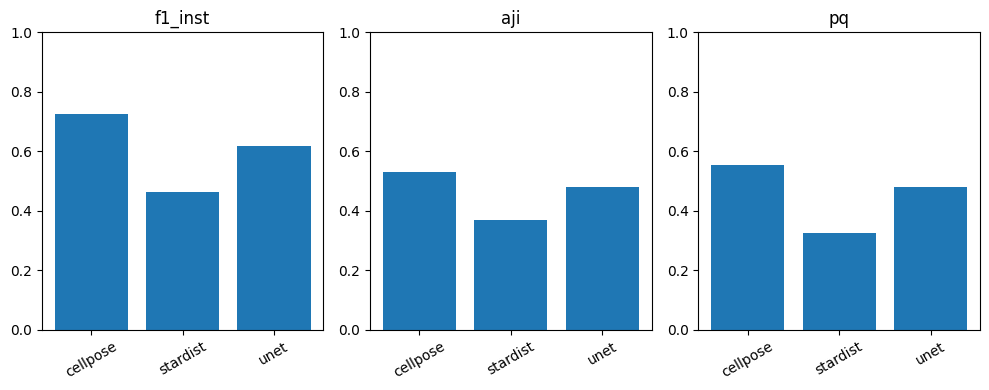

In [16]:
# Barplot comparatif (val)
import matplotlib.pyplot as plt

order = summary_val.index.tolist()
plt.figure(figsize=(10,4))
for j, m in enumerate(["f1_inst","aji","pq"]):
    plt.subplot(1,3,j+1)
    vals = summary_val[(m,"mean")].reindex(order)
    plt.bar(order, vals)
    plt.title(m)
    plt.ylim(0,1)
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Taille et morphologie (val)
Analyse des biais par classe morphologique et par taille (quantiles d'aire).


In [17]:
# Recall/IoU par morph_class
assert not df.empty, "df vide : re-executer le matching"

by_morph = df.groupby("morph_class").agg(
    n=("instance_id", "size"),
    unet_recall=("unet_TP", "mean"),
    stard_recall=("stardist_TP", "mean"),
    cellpose_recall=("cellpose_TP", "mean"),
    unet_iou=("unet_iou", "mean"),
    stard_iou=("stardist_iou", "mean"),
    cellpose_iou=("cellpose_iou", "mean"),
).reset_index()

by_morph

,morph_class,n,unet_recall,stard_recall,cellpose_recall,unet_iou,stard_iou,cellpose_iou
0,elongated,21951,0.009749,0.008883,0.008291,0.008717,0.007547,0.006660
1,irregular,3549,0.006481,0.002818,0.004790,0.005774,0.004216,0.004807
2,other,14332,0.010606,0.011792,0.010745,0.009173,0.009048,0.008671
3,round,11887,0.011862,0.012703,0.011273,0.009794,0.009956,0.008987


In [18]:
# Taille (quantiles d'aire) -> performance
q_bins = pd.qcut(df["area"], q=5, duplicates="drop")
by_area = df.assign(area_bin=q_bins).groupby("area_bin").agg(
    n=("instance_id","size"),
    unet_recall=("unet_TP","mean"),
    stard_recall=("stardist_TP","mean"),
    cellpose_recall=("cellpose_TP","mean"),
    unet_iou=("unet_iou","mean"),
    stard_iou=("stardist_iou","mean"),
    cellpose_iou=("cellpose_iou","mean"),
).reset_index()
by_area


C:\Users\yehadji\AppData\Local\Temp\ipykernel_321976\398358259.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_area = df.assign(area_bin=q_bins).groupby("area_bin").agg(


,area_bin,n,unet_recall,stard_recall,cellpose_recall,unet_iou,stard_iou,cellpose_iou
0,"(0.999, 163.0]",10387,0.003562,0.002214,0.000481,0.003003,0.002671,0.000470
1,"(163.0, 307.0]",10334,0.007645,0.007354,0.006483,0.006157,0.005576,0.004830
2,"(307.0, 476.0]",10328,0.010941,0.013362,0.012393,0.009900,0.010125,0.009347
3,"(476.0, 766.0]",10338,0.012768,0.013252,0.012188,0.010659,0.010267,0.009798
4,"(766.0, 12805.0]",10332,0.016357,0.014615,0.015583,0.014758,0.012833,0.013717


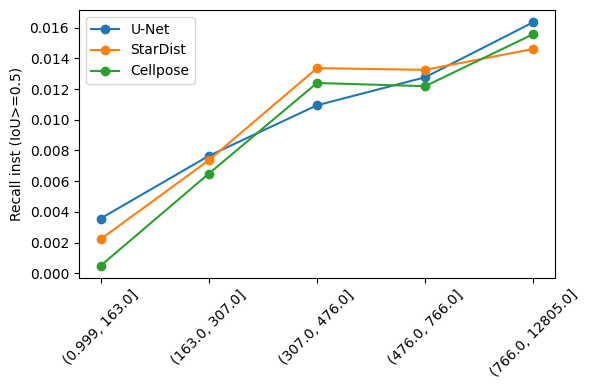

In [19]:
# Plot rappel par taille (recall)
plt.figure(figsize=(6,4))
for col, label, color in [
    ("unet_recall","U-Net","tab:blue"),
    ("stard_recall","StarDist","tab:orange"),
    ("cellpose_recall","Cellpose","tab:green"),
]:
    plt.plot(range(len(by_area)), by_area[col], marker='o', label=label, color=color)
plt.xticks(range(len(by_area)), by_area['area_bin'], rotation=45)
plt.ylabel('Recall inst (IoU>=0.5)')
plt.legend()
plt.tight_layout()
plt.show()


## Contact / chevauchement (val)
Impact du proxy de contact (touching ratio) sur le rappel moyen par image.


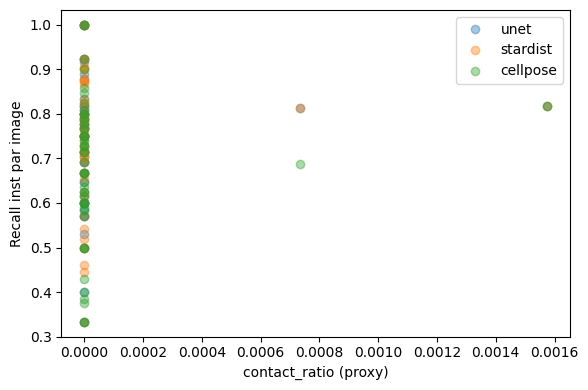

In [20]:
# Courbe recall vs contact_ratio
assert 'contact_ratio' in val_img_metrics.columns, "contact stats manquantes"
plt.figure(figsize=(6,4))
for model, color in [("unet","tab:blue"),("stardist","tab:orange"),("cellpose","tab:green")]:
    sub = val_img_metrics[val_img_metrics["model"]==model]
    plt.plot(sub["contact_ratio"], sub["recall"], 'o', alpha=0.4, label=model)
plt.xlabel('contact_ratio (proxy)')
plt.ylabel('Recall inst par image')
plt.legend()
plt.tight_layout()
plt.show()


## Robustesse au bruit
Evolution des metriques (val) quand on augmente le sigma du bruit gaussien.


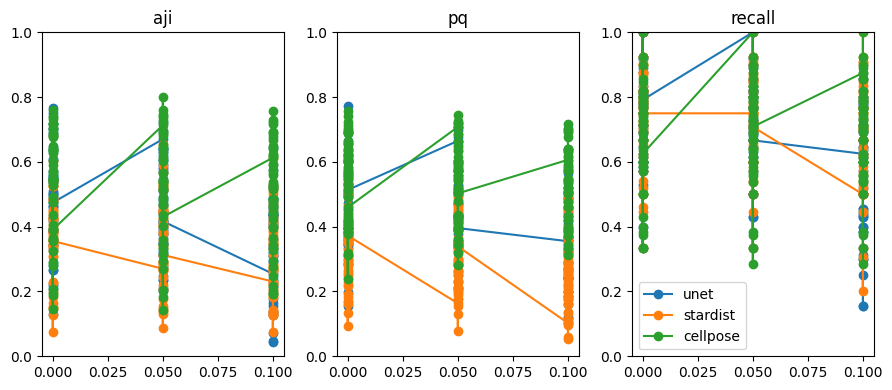

In [21]:
# Courbe AJI / PQ / Recall en fonction de sigma
assert not noise_df.empty, "noise_df vide : executer la cellule de stress test"
plt.figure(figsize=(9,4))
for j, m in enumerate(["aji","pq","recall"]):
    plt.subplot(1,3,j+1)
    for model, color in [("unet","tab:blue"),("stardist","tab:orange"),("cellpose","tab:green")]:
        sub = noise_df[noise_df["model"]==model]
        plt.plot(sub["sigma"], sub[m], marker='o', label=model)
    plt.title(m)
    plt.ylim(0,1)
plt.legend()
plt.tight_layout()
plt.show()
